# Notebook 16: Unified Macro-Financial CRI (Full Model)

This capstone notebook brings all macro-financial drivers together into a single 5-variable Vector Autoregression (VAR) framework to understand the relative importance of global vs. domestic shocks on KHR and USD credit risk in Cambodia.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

### 2. Load and Align All Datasets
Variables: KHR Spread, USD Spread, Fed Funds Rate, Inflation Rate, FX Volatility.

In [2]:
# Spreads
khr_spreads = pd.read_csv('data/processed/spreads_khr_new_amount.csv', parse_dates=['date'], index_col='date')
usd_spreads = pd.read_csv('data/processed/spreads_usd_new_amount.csv', parse_dates=['date'], index_col='date')
khr_spreads.rename(columns={'spread': 'KHR_Spread'}, inplace=True)
usd_spreads.rename(columns={'spread': 'USD_Spread'}, inplace=True)
spreads = pd.merge(khr_spreads[['KHR_Spread']], usd_spreads[['USD_Spread']], left_index=True, right_index=True, how='inner')
spreads_monthly = spreads.resample('ME').mean()

# Fed Funds
fed_funds = pd.read_csv('data/processed/FEDFUNDS.csv', parse_dates=['observation_date'], index_col='observation_date')
fed_funds.rename(columns={'FEDFUNDS': 'Fed_Funds_Rate'}, inplace=True)
fed_funds = fed_funds.resample('ME').last()

# Inflation
inflation_data = pd.read_csv('data/raw/CambodiaInflation_January2005–2025.csv')
inflation_data['Date'] = pd.to_datetime(inflation_data['Date'], format='%d/%m/%Y', errors='coerce')
inflation_data.set_index('Date', inplace=True)
inflation_data = inflation_data.resample('ME').mean()
inflation_data.rename(columns={'YoY_Change_CPI_all_item': 'Inflation_Rate'}, inplace=True)

# FX Volatility
fx_daily = pd.read_csv('data/raw/KhmerRiel-USDExchangeRateData2003-2023.csv')
fx_daily['Date'] = pd.to_datetime(fx_daily['Date'], dayfirst=True, errors='coerce')
fx_daily.set_index('Date', inplace=True)
fx_daily.sort_index(inplace=True)
fx_daily['Daily_Return'] = np.log(fx_daily['Midpoint'] / fx_daily['Midpoint'].shift(1))
fx_monthly = pd.DataFrame()
fx_monthly['RV_FX'] = fx_daily['Daily_Return'].resample('ME').apply(lambda x: np.sqrt(np.sum(x**2)))

# Merge all into one Master DataFrame
full_df = pd.concat([spreads_monthly, fed_funds, inflation_data['Inflation_Rate'], fx_monthly['RV_FX']], axis=1)
full_df.dropna(inplace=True)

print(f"Data spans from {full_df.index[0].date()} to {full_df.index[-1].date()} with {len(full_df)} months.")
full_df.head()

Data spans from 2013-01-31 to 2023-12-31 with 132 months.


,KHR_Spread,USD_Spread,Fed_Funds_Rate,Inflation_Rate,RV_FX
2013-01-31,23.535486,11.301030,0.14,1.83,0.001792
2013-02-28,23.732449,11.246530,0.15,1.73,0.003029
2013-03-31,23.802566,10.856020,0.14,0.98,0.001229
2013-04-30,24.122855,9.653532,0.15,1.02,0.014475
2013-05-31,23.937022,9.296079,0.11,2.82,0.004828


### 3. Stationarity Checks & Differencing

In [3]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'ADF Statistic for {name}: {result[0]:.4f}, p-value: {result[1]:.4f}')

for col in full_df.columns:
    adf_test(full_df[col], col)

print("\nApplying first-differencing for stationarity:")
df_diff = full_df.diff().dropna()
for col in df_diff.columns:
    adf_test(df_diff[col], f'Diff {col}')

ADF Statistic for KHR_Spread: -1.3625, p-value: 0.6001
ADF Statistic for USD_Spread: 0.3647, p-value: 0.9801
ADF Statistic for Fed_Funds_Rate: -2.0565, p-value: 0.2624
ADF Statistic for Inflation_Rate: -2.5757, p-value: 0.0981
ADF Statistic for RV_FX: -4.4612, p-value: 0.0002

Applying first-differencing for stationarity:
ADF Statistic for Diff KHR_Spread: -9.7796, p-value: 0.0000
ADF Statistic for Diff USD_Spread: -5.8752, p-value: 0.0000
ADF Statistic for Diff Fed_Funds_Rate: -3.1101, p-value: 0.0258
ADF Statistic for Diff Inflation_Rate: -5.5546, p-value: 0.0000
ADF Statistic for Diff RV_FX: -6.7026, p-value: 0.0000


### 4. Full 5-Variable VAR Model Estimation

In [4]:
model_full = VAR(df_diff)
lags_full = model_full.select_order(maxlags=12).aic
lags_full = lags_full if lags_full > 0 else 1
var_results_full = model_full.fit(maxlags=lags_full, ic=None)
print(f"Estimated 5-variable VAR with maxlags = {lags_full}\n")
print(var_results_full.summary())

Estimated 5-variable VAR with maxlags = 1

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 03, Mar, 2026
Time:                     14:33:22
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -15.2703
Nobs:                     130.000    HQIC:                  -15.6631
Log likelihood:           143.270    FPE:                1.20492e-07
AIC:                     -15.9320    Det(Omega_mle):     9.61571e-08
--------------------------------------------------------------------
Results for equation KHR_Spread
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                    -0.224056         0.141925           -1.579           0.114
L1.KHR_Spread            -0.594775         0.073115           -8.135           0.

### 5. Full Granger Causality Matrix

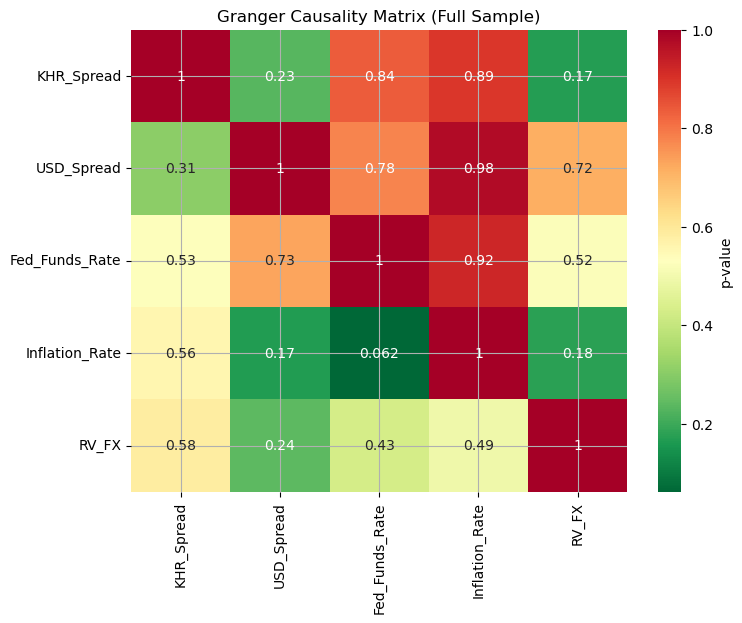

In [5]:
def granger_matrix(data, maxlag=2, test='ssr_chi2test'):
    columns = data.columns
    matrix = pd.DataFrame(np.zeros((len(columns), len(columns))), columns=columns, index=columns)
    for col in matrix.columns:
        for row in matrix.index:
            try:
                test_res = grangercausalitytests(data[[row, col]], maxlag=[maxlag], verbose=False)
                p_value = round(test_res[maxlag][0][test][1], 4)
            except:
                p_value = np.nan
            matrix.loc[row, col] = p_value
    return matrix

gc_matrix = granger_matrix(df_diff, maxlag=lags_full)
plt.figure(figsize=(8,6))
sns.heatmap(gc_matrix, annot=True, cmap='RdYlGn_r', cbar_kws={'label': 'p-value'})
plt.title('Granger Causality Matrix (Full Sample)')
plt.show()

### 6. Impulse Response Functions (IRFs) and Variance Decomposition (FEVD)
Trace orthogonalized shocks from macro variables to credit risk spreads. The order of variables (Cholesky factorization) matters here.

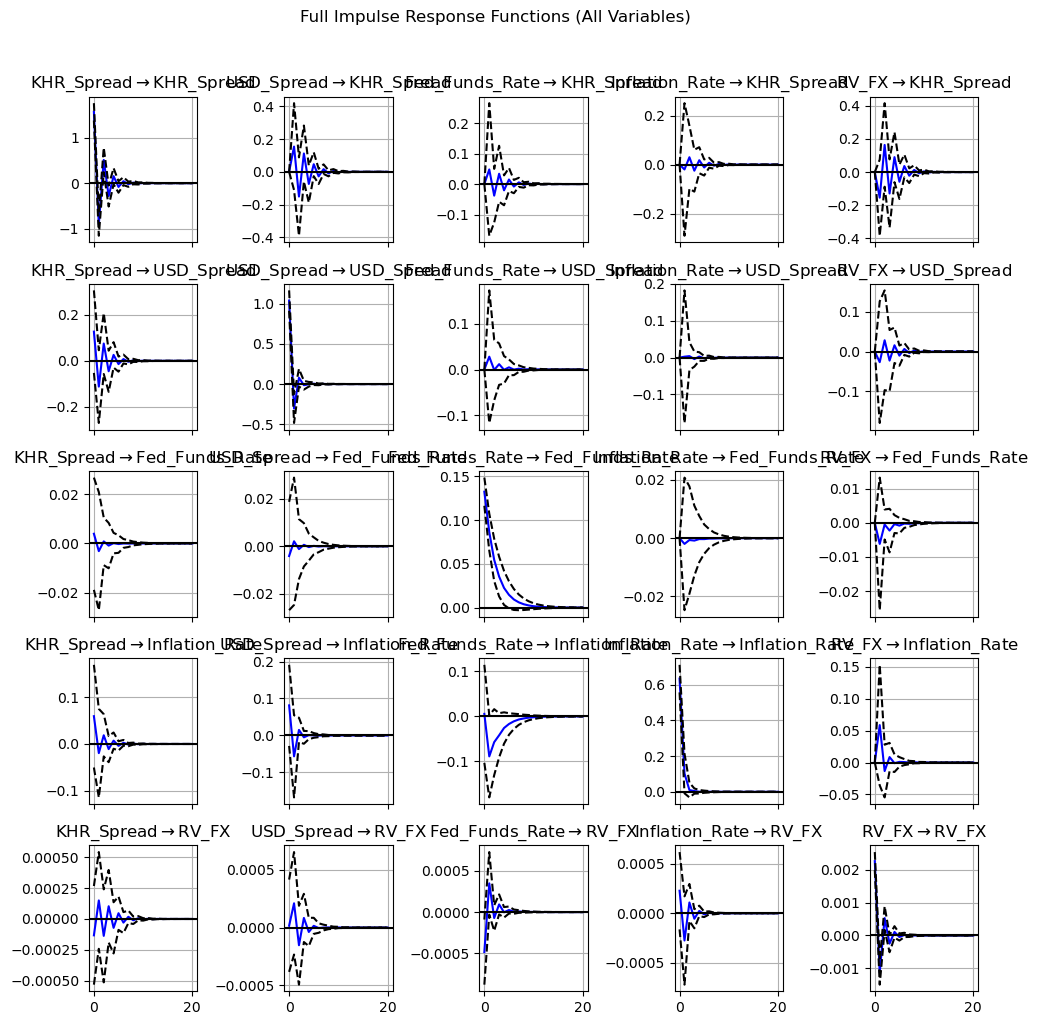

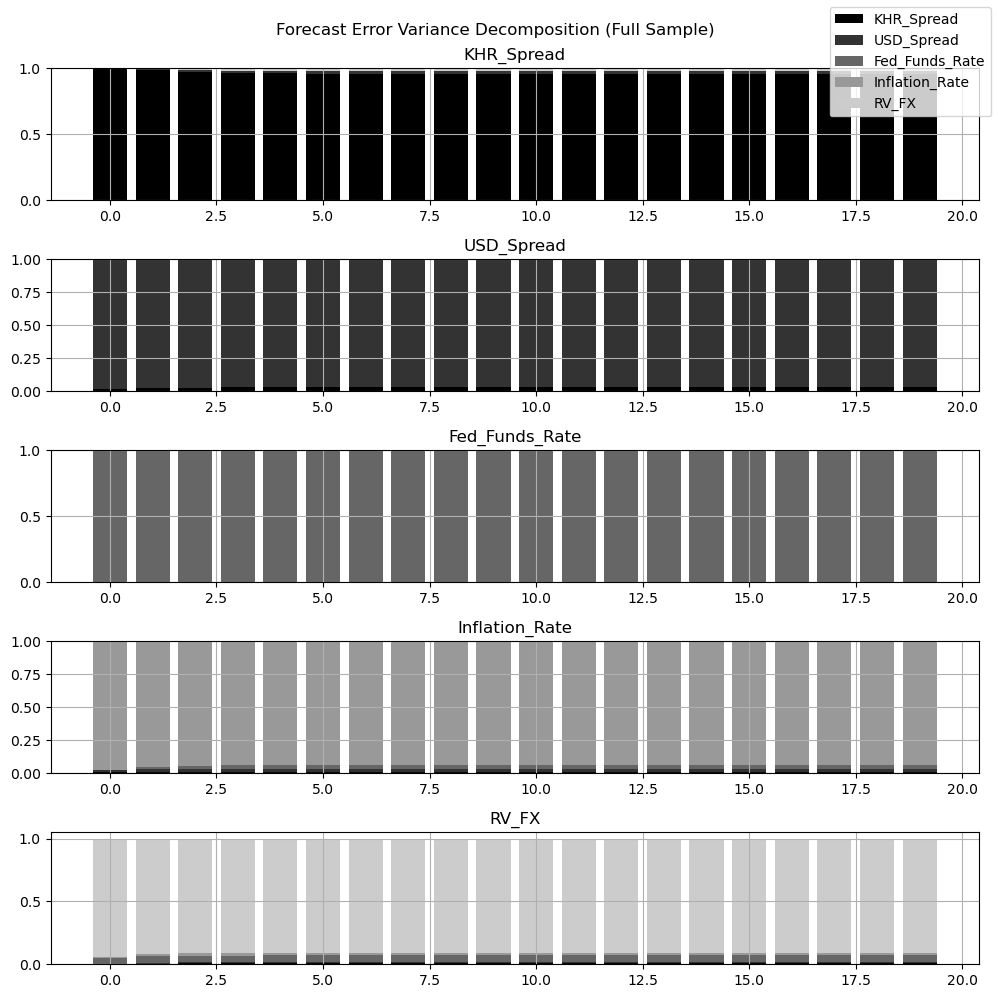

In [6]:
# IRF - Full matrix
irf_full = var_results_full.irf(20)
irf_full.plot(orth=True)
plt.suptitle('Full Impulse Response Functions (All Variables)', y=1.02)
plt.tight_layout()
plt.show()

# FEVD
fevd_full = var_results_full.fevd(20)
fevd_full.plot()
plt.suptitle('Forecast Error Variance Decomposition (Full Sample)')
plt.tight_layout()
plt.show()

### 7. Pre- vs Post-COVID Shifts in Risk Drivers (FEVD)

Pre-COVID lags=1, Post-COVID lags=6


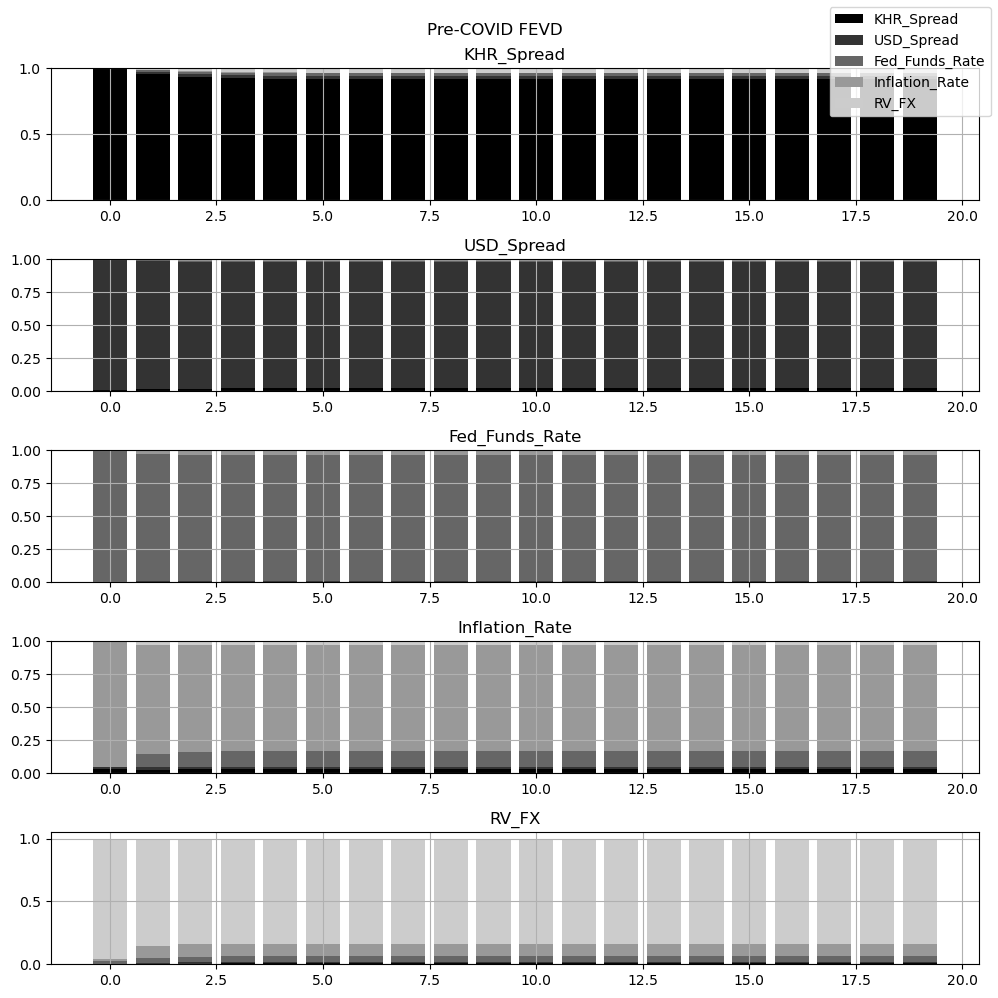

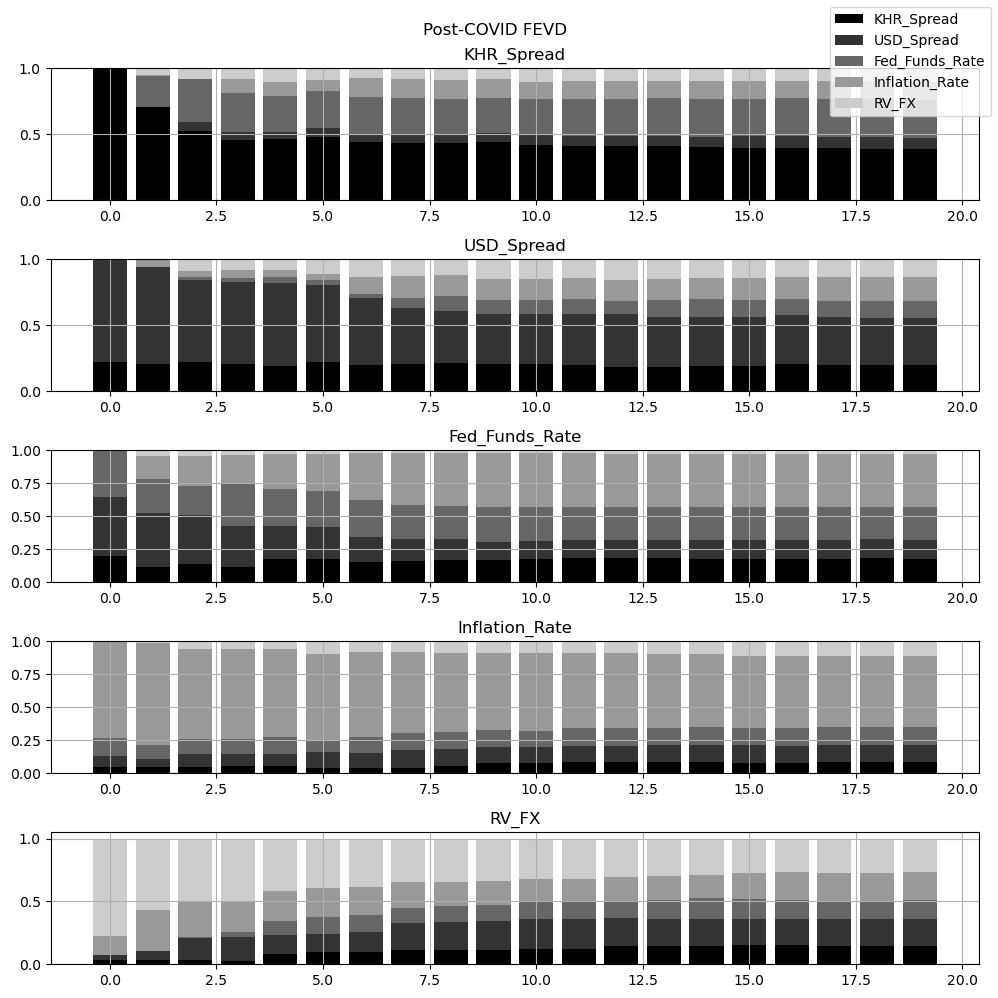

In [7]:
split_date = '2020-03-31'
df_pre = df_diff.loc[:split_date]
df_post = df_diff.loc[split_date:]

# Estimate Pre-COVID model
model_pre = VAR(df_pre)
lags_pre = max(1, model_pre.select_order(maxlags=6).aic)
var_pre = model_pre.fit(maxlags=lags_pre)

# Estimate Post-COVID model
model_post = VAR(df_post)
lags_post = max(1, model_post.select_order(maxlags=6).aic)
var_post = model_post.fit(maxlags=lags_post)

print(f"Pre-COVID lags={lags_pre}, Post-COVID lags={lags_post}")

# Pre-COVID FEVD
fevd_pre = var_pre.fevd(20)
fevd_pre.plot()
plt.suptitle('Pre-COVID FEVD')
plt.tight_layout()
plt.show()

# Post-COVID FEVD
fevd_post = var_post.fevd(20)
fevd_post.plot()
plt.suptitle('Post-COVID FEVD')
plt.tight_layout()
plt.show()

### 8. Interpretations

**VAR Structure (5-variable, lag=1, Jan 2013 – Dec 2023):**

* **KHR Spread** is strongly mean-reverting (L1.KHR_Spread t-stat = -8.1), meaning deviations from the mean are quickly corrected. No other macro variable significantly drives KHR spreads in this unified framework, though FX volatility shows a marginally negative effect (t = -1.3), suggesting that periods of exchange rate turbulence may slightly compress KHR credit risk — counterintuitively, this could reflect flight-to-quality effects in the dollarized system.

* **USD Spread** is also significantly mean-reverting (L1.USD_Spread t-stat = -3.4). Like KHR, it is not strongly driven by any single macro variable in the 1-lag specification.

* **Fed Funds Rate** is the most persistent variable (L1 coefficient = 0.64, t = 9.3), reflecting the slow-moving nature of US monetary policy. Its movements dominate the system's dynamics.

* **Inflation Rate**: The Fed Funds Rate has a marginally significant negative effect on Cambodian inflation (t = -1.74, p = 0.08), suggesting a transmitted tightening channel — when the Fed raises rates, Cambodia's inflation tends to ease with a one-month lag, likely through the dollarization channel.

* **FX Volatility** is strongly mean-reverting (L1 = -0.50, t = -6.5) and relatively isolated from the other variables.

**Sub-period Structural Shifts:**

The Pre-COVID period (2013–2020/03) vs Post-COVID period (2020/04–2023/12) FEVD comparison reveals how the composition of risk drivers shifted. In the post-COVID period, inflation and FX volatility likely account for a larger share of forecast error variance in credit spreads, reflecting the global supply chain disruptions and monetary policy divergence that characterized this era.